In [16]:
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("../data/the_weeknd_setlists.csv", parse_dates=["event_date"])
df.head()

,event_date,venue,city,country,tour,set_name,song_name,is_cover,info
0,2026-07-12,Stade de France,Saint-Denis,France,After Hours Til Dawn,main,Baptized in Fear,False,Shortened
1,2026-07-12,Stade de France,Saint-Denis,France,After Hours Til Dawn,main,Open Hearts,False,Shortened
2,2026-07-12,Stade de France,Saint-Denis,France,After Hours Til Dawn,main,Wake Me Up,False,Shortened
3,2026-07-12,Stade de France,Saint-Denis,France,After Hours Til Dawn,main,After Hours,False,Shortened
4,2026-07-12,Stade de France,Saint-Denis,France,After Hours Til Dawn,main,Starboy,False,NaN


In [3]:
print(df.shape)
print(df["event_date"].min(), "to", df["event_date"].max())
print(df["tour"].value_counts())

(11405, 9)
2010-11-01 00:00:00 to 2026-07-12 00:00:00
tour
After Hours Til Dawn           4968
Starboy: Legend of the Fall    2158
The Madness Fall Tour           608
Kiss Land Fall Tour             527
The Fall Tour                   440
Asia Tour                       142
King of the Fall Tour           130
Name: count, dtype: int64


In [4]:
song_counts = df["song_name"].value_counts()
song_counts.head(20)

song_name
Wicked Games                             442
The Morning                              372
Crew Love                                339
The Hills                                327
Often                                    322
Can't Feel My Face                       289
High for This                            271
Starboy                                  267
I Feel It Coming                         255
House of Balloons / Glass Table Girls    214
Earned It                                197
Party Monster                            191
Low Life                                 186
Or Nah                                   174
Reminder                                 166
Call Out My Name                         152
Acquainted                               151
Blinding Lights                          147
In the Night                             147
The Party & the After Party              144
Name: count, dtype: int64

In [ ]:
tour_name = "After Hours Til Dawn"
tour_df = df[df["tour"] == tour_name]

# One row per show, the set of songs played
show_setlists = tour_df.groupby(["event_date", "venue"])["song_name"].apply(set).reset_index()
show_setlists = show_setlists.sort_values("event_date").reset_index(drop=True)

# Jaccard similarity between each show and the next one on the same tour
def jaccard(set_a, set_b):
    return len(set_a & set_b) / len(set_a | set_b)

similarities = []
for i in range(len(show_setlists) - 1):
    sim = jaccard(show_setlists.loc[i, "song_name"], show_setlists.loc[i+1, "song_name"])
    similarities.append(sim)

pd.Series(similarities).describe()

count    129.000000
mean       0.944402
std        0.126650
min        0.166667
25%        0.947368
50%        0.976744
75%        1.000000
max        1.000000
dtype: float64

In [ ]:
tour_df = df[df["tour"] == tour_name]

# how many times does each song appear out of total number of shows in this tour
total_shows = tour_df.groupby(["event_date", "venue"]).ngroups
song_show_counts = tour_df.groupby("song_name")["event_date"].nunique()
song_play_rate = (song_show_counts / total_shows).sort_values(ascending=False)

print(song_play_rate)

song_name
Can't Feel My Face            1.000000
How Do I Make You Love Me?    1.000000
Sacrifice                     1.000000
Less Than Zero                0.992308
Is There Someone Else?        0.992308
                                ...   
Hurry Up Tomorrow             0.007692
Jealous Guy                   0.007692
Like a God                    0.007692
Coming Down                   0.007692
Dirty Diana                   0.007692
Name: event_date, Length: 91, dtype: float64


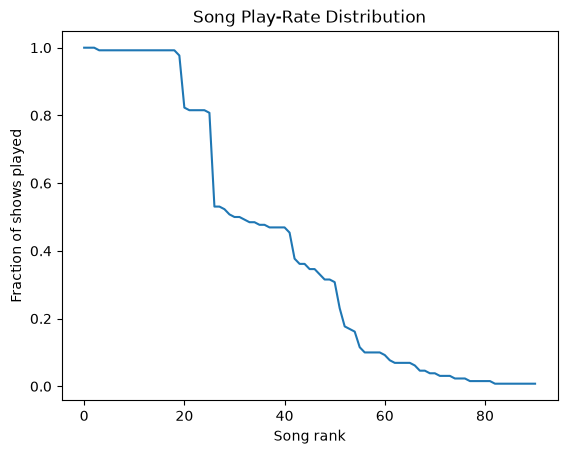

In [17]:
song_play_rate.reset_index(drop=True).plot(kind="line")
plt.ylabel("Fraction of shows played")
plt.xlabel("Song rank")
plt.title("Song Play-Rate Distribution")
plt.show()